# CIS 509  Unstructured Data Analysis
## Lab Assignment 5 BERTopic Modeling on Restaurant Reviews
**Author:** Matthew Cook  
**ASU ID:** MCOOK20  
**Date Created:** April 27, 2026  
**Dataset:** Yelp Restaurant Reviews – Arizona (48,147 reviews)




In [1]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Install all required packages ─────────────────────────────────────────
!pip install -q bertopic
!pip install -q umap-learn
!pip install -q hdbscan
!pip install -q sentence-transformers
!pip install -q plotly
!pip install -q datamapplot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.6/342.6 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 123.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 67.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 26.2.0 requires dask==2026.1.1, but you have dask 2026.3.0 which is incompatible.
rapids-dask-dependency 26.2.0 requires distributed==2026.1.1, but you have distributed 2026.3.0 which is incompatible.


In [3]:
# ── Code Cell 1: Library and Data Import ──────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import date

from bertopic import BERTopic
from umap import UMAP
from sentence_transformers import SentenceTransformer

# ── ASU color palette ──────────────────────────────────────────────────────
ASU_MAROON = "#8C1D40"
ASU_GOLD   = "#FFC627"
ASU_DARK   = "#191919"
ASU_WHITE  = "#FFFFFF"
ASU_GRAY   = "#747474"

plt.rcParams["figure.facecolor"] = ASU_DARK
plt.rcParams["axes.facecolor"]   = ASU_DARK
plt.rcParams["axes.edgecolor"]   = ASU_GOLD
plt.rcParams["axes.labelcolor"]  = ASU_WHITE
plt.rcParams["xtick.color"]      = ASU_WHITE
plt.rcParams["ytick.color"]      = ASU_WHITE
plt.rcParams["text.color"]       = ASU_WHITE
plt.rcParams["grid.color"]       = ASU_GRAY
plt.rcParams["grid.alpha"]       = 0.3

# ── Load data ──────────────────────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/"

df = pd.read_csv(DATA_PATH + "restaurant_reviews_az.csv", header=0)

# Parse date column
df["date"] = pd.to_datetime(df["date"])

print(f"Dataset shape:  {df.shape}")
print(f"Columns:        {list(df.columns)}")
print(f"Date range:     {df['date'].min()} to {df['date'].max()}")
print(f"\nStar distribution:")
print(df["stars"].value_counts().sort_index())
print(f"\nRun date: {date.today()}")
df.head()

Dataset shape:  (48147, 9)
Columns:        ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']
Date range:     2020-01-01 00:49:00 to 2022-01-19 19:22:00

Star distribution:
stars
1     8466
2     3846
3     4054
4     7314
5    24467
Name: count, dtype: int64

Run date: 2026-04-27


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,IVS7do_HBzroiCiymNdxDg,fdFgZQQYQJeEAshH4lxSfQ,sGy67CpJctjeCWClWqonjA,3,1,1,0,"OK, the hype about having Hatch chili in your ...",2020-01-27 22:59:00
1,QP2pSzSqpJTMWOCuUuyXkQ,JBLWSXBTKFvJYYiM-FnCOQ,3w7NRntdQ9h0KwDsksIt5Q,5,1,1,1,Pandemic pit stop to have an ice cream.... onl...,2020-04-19 05:33:00
2,oK0cGYStgDOusZKz9B1qug,2_9fKnXChUjC5xArfF8BLg,OMnPtRGmbY8qH_wIILfYKA,5,1,0,0,I was lucky enough to go to the soft opening a...,2020-02-29 19:43:00
3,E_ABvFCNVLbfOgRg3Pv1KQ,9MExTQ76GSKhxSWnTS901g,V9XlikTxq0My4gE8LULsjw,5,0,0,0,I've gone to claim Jumpers all over the US and...,2020-03-14 21:47:00
4,Rd222CrrnXkXukR2iWj69g,LPxuausjvDN88uPr-Q4cQA,CA5BOxKRDPGJgdUQ8OUOpw,4,1,0,0,"If you haven't been to Maynard's kitchen, it'...",2020-01-17 20:32:00


Review Length Statistics:
  Mean:    86.9 words
  Median:  63.0 words
  Min:     1 words
  Max:     955 words
  Std Dev: 78.7 words


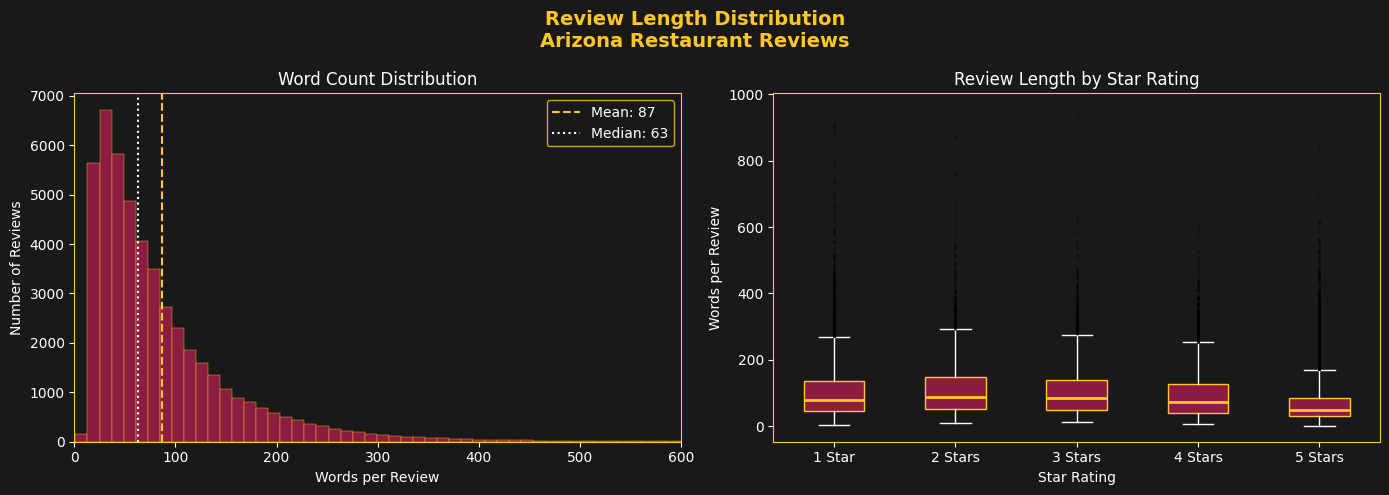

Plot saved to Drive.


In [4]:
# ── Code Cell 2: Review Length Distribution ───────────────────────────────

# Calculate review length in words
df["review_length"] = df["text"].apply(lambda x: len(str(x).split()))

# Summary statistics
print("Review Length Statistics:")
print(f"  Mean:    {df['review_length'].mean():.1f} words")
print(f"  Median:  {df['review_length'].median():.1f} words")
print(f"  Min:     {df['review_length'].min()} words")
print(f"  Max:     {df['review_length'].max()} words")
print(f"  Std Dev: {df['review_length'].std():.1f} words")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Review Length Distribution\nArizona Restaurant Reviews",
             color=ASU_GOLD, fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(df["review_length"], bins=80,
             color=ASU_MAROON, edgecolor=ASU_GOLD, linewidth=0.3)
axes[0].axvline(df["review_length"].mean(),
                color=ASU_GOLD, linestyle="--", linewidth=1.5,
                label=f"Mean: {df['review_length'].mean():.0f}")
axes[0].axvline(df["review_length"].median(),
                color=ASU_WHITE, linestyle=":", linewidth=1.5,
                label=f"Median: {df['review_length'].median():.0f}")
axes[0].set_xlim(0, 600)
axes[0].set_title("Word Count Distribution", color=ASU_WHITE)
axes[0].set_xlabel("Words per Review")
axes[0].set_ylabel("Number of Reviews")
axes[0].legend(facecolor=ASU_DARK, edgecolor=ASU_GOLD)

# Box plot by star rating
star_groups = [df[df["stars"] == s]["review_length"].values for s in [1,2,3,4,5]]
bp = axes[1].boxplot(star_groups,
                     patch_artist=True,
                     medianprops=dict(color=ASU_GOLD, linewidth=2),
                     whiskerprops=dict(color=ASU_WHITE),
                     capprops=dict(color=ASU_WHITE),
                     flierprops=dict(marker=".", color=ASU_GOLD,
                                    alpha=0.2, markersize=2))
for patch in bp["boxes"]:
    patch.set_facecolor(ASU_MAROON)
    patch.set_edgecolor(ASU_GOLD)

axes[1].set_xticklabels(["1 Star","2 Stars","3 Stars","4 Stars","5 Stars"])
axes[1].set_title("Review Length by Star Rating", color=ASU_WHITE)
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Words per Review")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_length_dist.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()
print("Plot saved to Drive.")

In [5]:
# ── Code Cell 3: Build BERTopic Model with UMAP ───────────────────────────

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

# ── Prepare documents ─────────────────────────────────────────────────────
docs = df["text"].astype(str).tolist()
print(f"Total documents: {len(docs):,}")

# ── Sentence embeddings ───────────────────────────────────────────────────
print("Loading sentence transformer model...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generating embeddings (this takes 5-10 mins)...")
embeddings = embedding_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {embeddings.shape}")

# ── UMAP — per assignment spec ────────────────────────────────────────────
# target dimension 5, n_neighbors 15, cosine similarity
umap_model = UMAP(
    n_components  = 5,
    n_neighbors   = 15,
    metric        = "cosine",
    random_state  = 42
)

# ── HDBSCAN for clustering ────────────────────────────────────────────────
hdbscan_model = HDBSCAN(
    min_cluster_size = 50,
    metric           = "euclidean",
    prediction_data  = True
)

# ── Build BERTopic model ──────────────────────────────────────────────────
print("Fitting BERTopic model...")
topic_model = BERTopic(
    umap_model    = umap_model,
    hdbscan_model = hdbscan_model,
    language      = "english",
    calculate_probabilities = False,
    verbose       = True
)

topics, _ = topic_model.fit_transform(docs, embeddings)

# ── Results summary ───────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info) - 1  # subtract outlier topic -1

print(f"\nTopics discovered:   {n_topics}")
print(f"Outlier documents:   {(pd.Series(topics) == -1).sum():,}")
print(f"\nTop 10 topics by document count:")
print(topic_info[topic_info["Topic"] != -1].head(10)[
    ["Topic","Count","Name"]
])

Total documents: 48,147
Loading sentence transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/753 [00:00<?, ?it/s]

2026-04-27 18:36:02,162 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Embeddings shape: (48147, 384)
Fitting BERTopic model...


2026-04-27 18:37:29,090 - BERTopic - Dimensionality - Completed ✓
2026-04-27 18:37:29,092 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-27 18:37:40,130 - BERTopic - Cluster - Completed ✓
2026-04-27 18:37:40,144 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-27 18:37:42,993 - BERTopic - Representation - Completed ✓



Topics discovered:   80
Outlier documents:   24,011

Top 10 topics by document count:
    Topic  Count                             Name
1       0   3456          0_great_food_service_is
2       1   2724                1_she_to_we_order
3       2   1487          2_pizza_crust_pizzas_it
4       3   1109       3_burger_fries_burgers_the
5       4   1084               4_tucson_in_is_and
6       5    865           5_tacos_taco_the_asada
7       6    649        6_tucson_mexican_tacos_in
8       7    637  7_breakfast_toast_eggs_pancakes
9       8    633           8_sushi_roll_rolls_the
10      9    493          9_italian_pasta_the_and


Top 10 topics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



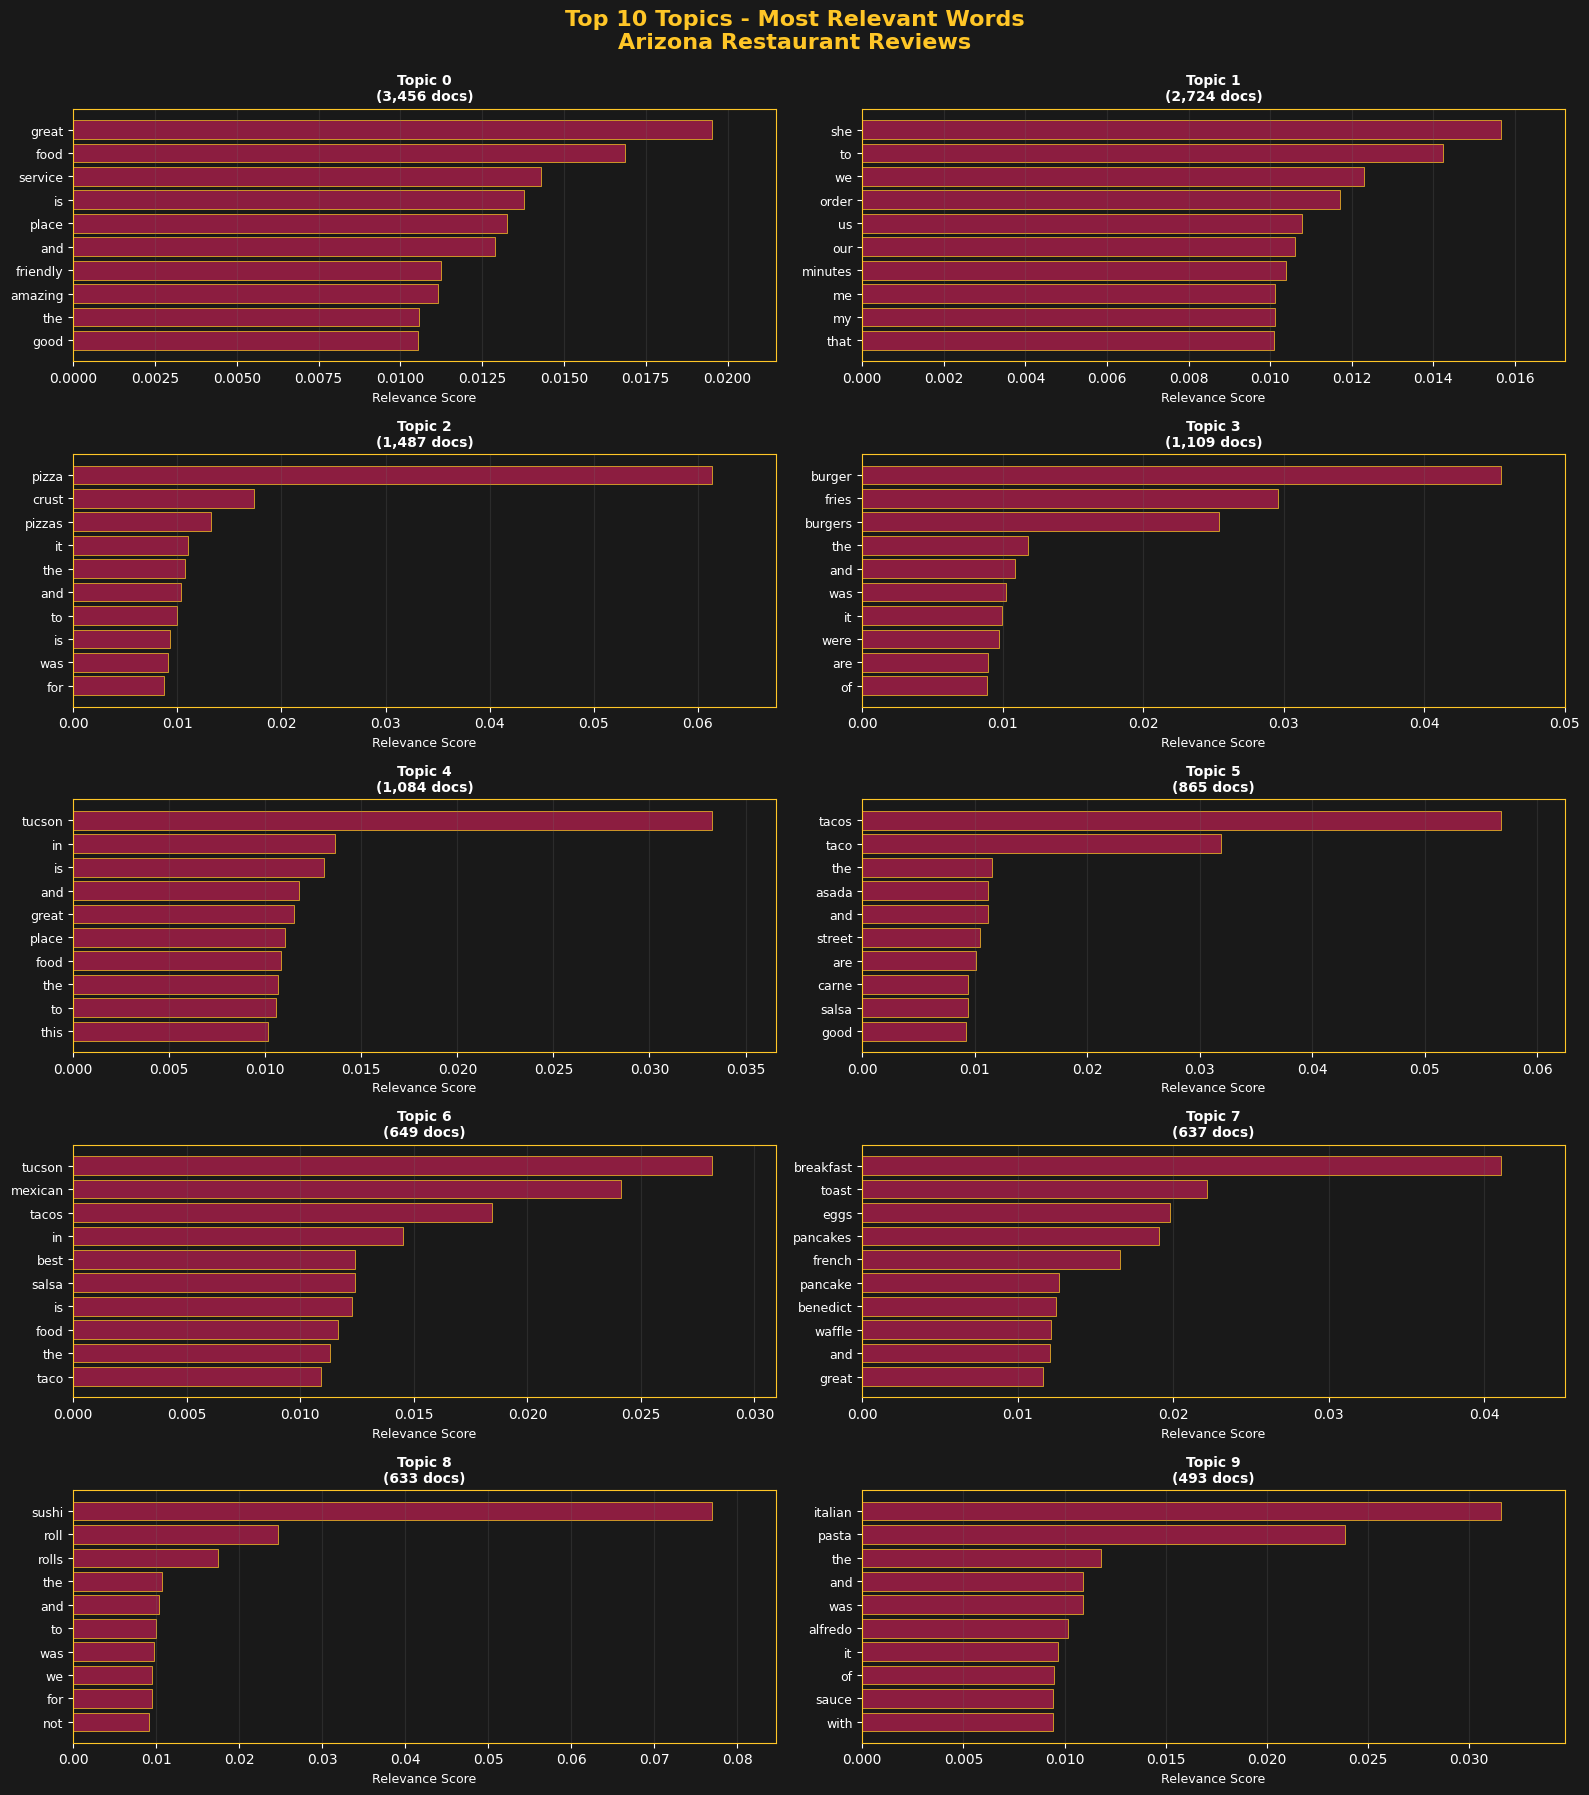

Top 10 topics visualized and saved to Drive.


In [6]:
# ── Code Cell 4: Visualize Most Relevant Words for Top 10 Topics ──────────

import matplotlib.pyplot as plt
import numpy as np

# Get top 10 topics by document count (excluding -1 outlier)
top_10_topics = topic_info[topic_info["Topic"] != -1].head(10)["Topic"].tolist()

print(f"Top 10 topics: {top_10_topics}\n")

# ── Create figure with subplots (5 rows x 2 cols) ────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(16, 18))
fig.suptitle("Top 10 Topics - Most Relevant Words\nArizona Restaurant Reviews",
             color=ASU_GOLD, fontsize=16, fontweight="bold", y=0.995)

axes = axes.flatten()

for idx, topic in enumerate(top_10_topics):
    # Get top 10 words for this topic
    words = topic_model.get_topic(topic)

    if words:
        words_list = [w[0] for w in words[:10]]
        scores = [w[1] for w in words[:10]]

        # Reverse for horizontal bars
        words_list = words_list[::-1]
        scores = scores[::-1]

        # Plot
        bars = axes[idx].barh(range(len(words_list)), scores,
                              color=ASU_MAROON, edgecolor=ASU_GOLD, linewidth=0.5)
        axes[idx].set_yticks(range(len(words_list)))
        axes[idx].set_yticklabels(words_list, fontsize=9)
        axes[idx].set_xlabel("Relevance Score", fontsize=9)
        axes[idx].set_title(f"Topic {topic}\n({topic_info[topic_info['Topic']==topic]['Count'].values[0]:,} docs)",
                           color=ASU_WHITE, fontweight="bold", fontsize=10)
        axes[idx].set_xlim(0, max(scores) * 1.1)
        axes[idx].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_top10_topics.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()

print("Top 10 topics visualized and saved to Drive.")

In [9]:
# ── Code Cell 5: Visualize Topic Hierarchy (Top 30 Topics) ──────────────

# Get top 30 topics by document count (excluding -1 outlier)
top_30_topics = topic_info[topic_info["Topic"] != -1].head(30)["Topic"].tolist()

print(f"Top 30 topics for hierarchy: {top_30_topics[:10]}... (showing first 10)")
print(f"Total topics in hierarchy: {len(top_30_topics)}")

# ── Reduce to top 30 for hierarchy visualization ───────────────────────────
topic_model_sub = topic_model.reduce_topics(docs, nr_topics=30)

# ── Generate hierarchy visualization ──────────────────────────────────────
fig_hierarchy = topic_model_sub.visualize_hierarchy(
    top_n_topics = 30,
    width        = 1400,
    height       = 800
)

# Save to Drive
fig_hierarchy.write_html("/content/drive/MyDrive/Colab Notebooks/LA5_topic_hierarchy_30.html")
print("\nHierarchy visualization saved as interactive HTML.")

# Display summary
print(f"Topic hierarchy created for {len(top_30_topics)} topics.")
print("Topics are clustered by similarity - similar topics branch together.")

# Show the hierarchy
fig_hierarchy.show()

2026-04-27 18:43:41,448 - BERTopic - Topic reduction - Reducing number of topics
2026-04-27 18:43:41,449 - BERTopic - Topic reduction - Number of topics (30) is equal or higher than the clustered topics(30).
2026-04-27 18:43:41,449 - BERTopic - Representation - Fine-tuning topics using representation models.


Top 30 topics for hierarchy: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]... (showing first 10)
Total topics in hierarchy: 30


2026-04-27 18:43:44,206 - BERTopic - Representation - Completed ✓



Hierarchy visualization saved as interactive HTML.
Topic hierarchy created for 30 topics.
Topics are clustered by similarity - similar topics branch together.


2026-04-27 18:44:44,098 - BERTopic - Topic reduction - Reducing number of topics
2026-04-27 18:44:44,146 - BERTopic - Representation - Fine-tuning topics using representation models.


Reducing BERTopic model from 80 topics to 15...


2026-04-27 18:44:47,017 - BERTopic - Representation - Completed ✓
2026-04-27 18:44:47,025 - BERTopic - Topic reduction - Reduced number of topics from 30 to 15


Model reduced to 14 topics

Top 15 topics by document count:
    Topic  Count                        Name
1       0  19069            0_the_and_was_to
2       1   2978             1_to_the_and_we
3       2    703       2_coffee_boba_tea_the
4       3    341         3_mask_masks_to_the
5       4    193           4_room_the_to_and
6       5    187     5_donuts_donut_cake_and
7       6    118      6_closed_open_hours_at
8       7    112    7_bagels_bagel_cream_and
9       8    103       8_gluten_free_and_the
10      9     89      9_panda_express_the_to
11     10     71   10_eegees_the_fries_eegee
12     11     69     11_chipotle_the_to_this
13     12     53  12_ethiopian_desta_and_the
14     13     50     13_postino_wine_and_the


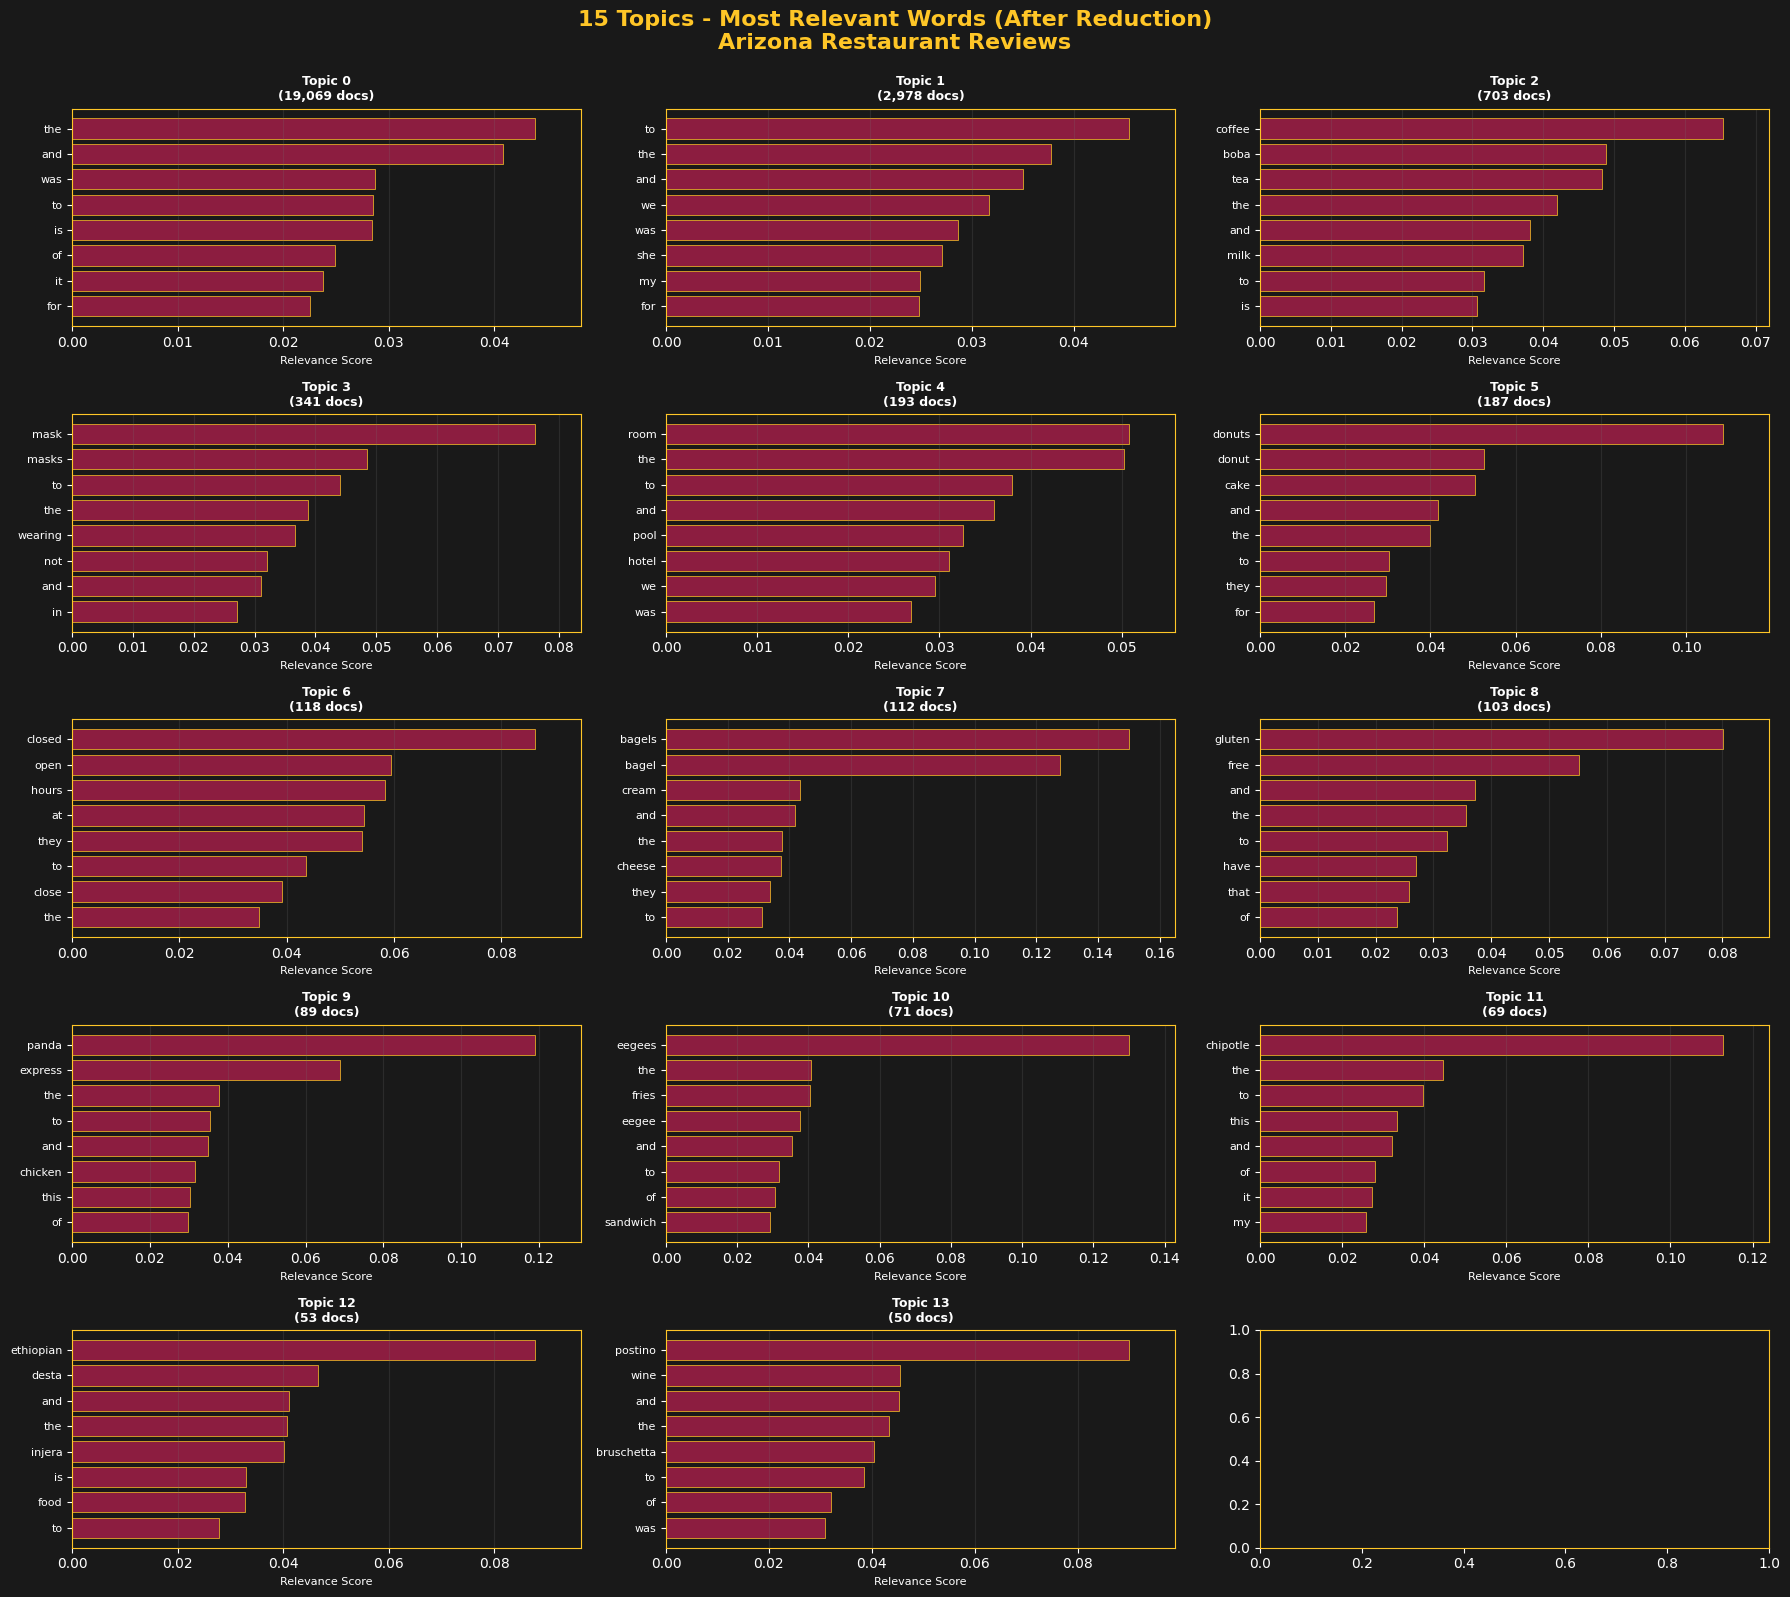

Top 15 topics word visualization saved.
Topic hierarchy for 15 topics saved as HTML.


In [10]:
# ── Code Cell 6: Reduce to 15 Topics, Visualize Words & Hierarchy ────────

# ── Reduce model to 15 topics ─────────────────────────────────────────────
print("Reducing BERTopic model from 80 topics to 15...")
topic_model_15 = topic_model.reduce_topics(docs, nr_topics=15)

# ── Get topic info for 15-topic model ─────────────────────────────────────
topic_info_15 = topic_model_15.get_topic_info()
n_topics_15 = len(topic_info_15) - 1

print(f"Model reduced to {n_topics_15} topics")
print(f"\nTop 15 topics by document count:")
print(topic_info_15[topic_info_15["Topic"] != -1][
    ["Topic","Count","Name"]
].head(15))

# ── Visualize top 15 topics (most relevant words) ─────────────────────────
fig_words, axes = plt.subplots(5, 3, figsize=(18, 16))
fig_words.suptitle("15 Topics - Most Relevant Words (After Reduction)\nArizona Restaurant Reviews",
                   color=ASU_GOLD, fontsize=16, fontweight="bold", y=0.995)

axes = axes.flatten()

for idx in range(15):
    words = topic_model_15.get_topic(idx)

    if words:
        words_list = [w[0] for w in words[:8]]
        scores = [w[1] for w in words[:8]]

        words_list = words_list[::-1]
        scores = scores[::-1]

        bars = axes[idx].barh(range(len(words_list)), scores,
                              color=ASU_MAROON, edgecolor=ASU_GOLD, linewidth=0.5)
        axes[idx].set_yticks(range(len(words_list)))
        axes[idx].set_yticklabels(words_list, fontsize=8)
        axes[idx].set_xlabel("Relevance Score", fontsize=8)

        count = topic_info_15[topic_info_15["Topic"]==idx]["Count"].values[0]
        axes[idx].set_title(f"Topic {idx}\n({count:,} docs)",
                           color=ASU_WHITE, fontweight="bold", fontsize=9)
        axes[idx].set_xlim(0, max(scores) * 1.1)
        axes[idx].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_topics_15_words.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()

print("Top 15 topics word visualization saved.")

# ── Topic hierarchy for 15 topics ────────────────────────────────────────
fig_hier_15 = topic_model_15.visualize_hierarchy(
    top_n_topics = 15,
    width        = 1400,
    height       = 700
)

fig_hier_15.write_html("/content/drive/MyDrive/Colab Notebooks/LA5_topic_hierarchy_15.html")
print("Topic hierarchy for 15 topics saved as HTML.")

fig_hier_15.show()

In [13]:
# ── Code Cell 7: Topic Allocation of First 5 Reviews ───────────────────────

# Use the topics already assigned from the original fit
# topics contains the topic assignment for each document
print("First 5 reviews - Topic allocation:\n")
print("="*90)

for i in range(5):
    review_text = df.iloc[i]["text"][:150]  # first 150 chars
    star_rating = df.iloc[i]["stars"]
    assigned_topic = topics[i]

    # Get topic info from the 15-topic model
    if assigned_topic != -1:
        topic_words = topic_model_15.get_topic(assigned_topic)
        top_words = [w[0] for w in topic_words[:5]]
        topic_name = topic_info_15[topic_info_15["Topic"]==assigned_topic]["Name"].values[0]
    else:
        top_words = ["(outlier)"]
        topic_name = "Outlier - No clear topic"

    print(f"\nReview {i+1}:")
    print(f"  Stars:        {star_rating}")
    print(f"  Topic:        {assigned_topic}")
    print(f"  Topic name:   {topic_name}")
    print(f"  Top words:    {', '.join(top_words)}")
    print(f"  Text:         \"{review_text}...\"")
    print("-"*90)

# Distribution of topics across all reviews using 15-topic model mapping
print("\n\nTopic distribution across all 48,147 reviews (15-topic model):")
topic_dist = pd.Series(topics).value_counts().sort_index()
print(topic_dist)

First 5 reviews - Topic allocation:


Review 1:
  Stars:        3
  Topic:        -1
  Topic name:   Outlier - No clear topic
  Top words:    (outlier)
  Text:         "OK, the hype about having Hatch chili in your burger is overrated. It's OK. I do like the kick. But it's an average burger. Good bun. Good fries. I ra..."
------------------------------------------------------------------------------------------

Review 2:
  Stars:        5
  Topic:        -1
  Topic name:   Outlier - No clear topic
  Top words:    (outlier)
  Text:         "Pandemic pit stop to have an ice cream.... only plain Sundae! Limited menu was written on the screens outside. So no unpleasant surprise.
Cashier was ..."
------------------------------------------------------------------------------------------

Review 3:
  Stars:        5
  Topic:        9
  Topic name:   9_panda_express_the_to
  Top words:    panda, express, the, to, and
  Text:         "I was lucky enough to go to the soft opening and let me tel

=== get_topic() — Topic 0 ===

Topic 0 — Full word list with relevance scores:

Rank   Word                 Score
1      the                  0.043851
2      and                  0.040803
3      was                  0.028710
4      to                   0.028540
5      is                   0.028420
6      of                   0.024911
7      it                   0.023774
8      for                  0.022559
9      in                   0.022483
10     food                 0.021325


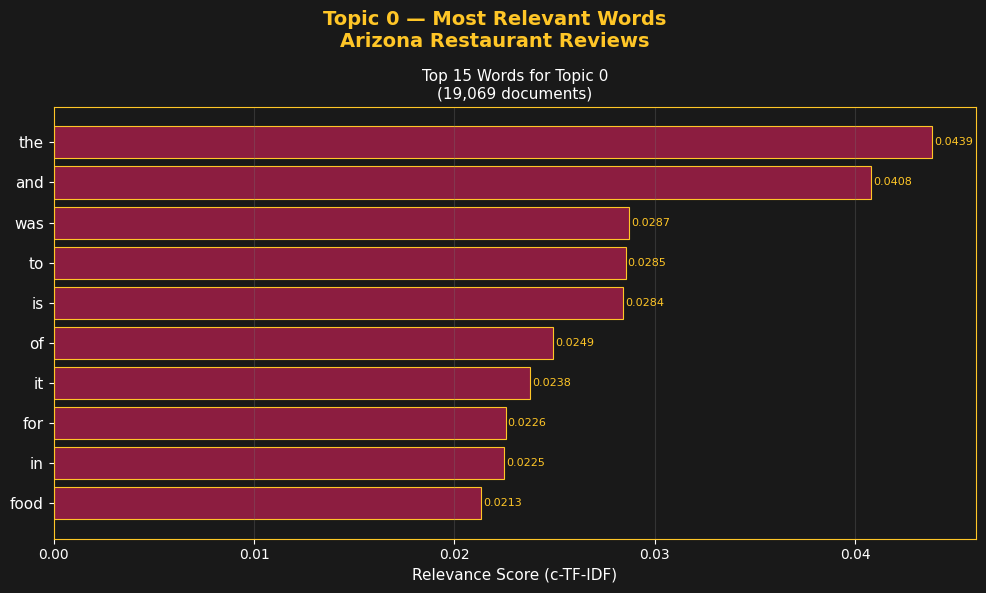

Topic 0 visualization saved to Drive.

=== get_topic() — Topics 1 and 2 for comparison ===

Topic 1 (2,978 docs): [('to', '0.0454'), ('the', '0.0378'), ('and', '0.0350'), ('we', '0.0317'), ('was', '0.0287')]
Topic 2 (703 docs): [('coffee', '0.0654'), ('boba', '0.0489'), ('tea', '0.0483'), ('the', '0.0420'), ('and', '0.0382')]


In [14]:
# ── Code Cell 8: get_topic() for Most Relevant Words — Topic 0 ────────────

# Use get_topic() to retrieve the most relevant words for topic 0
print("=== get_topic() — Topic 0 ===\n")
topic_0_words = topic_model_15.get_topic(0)

print(f"Topic 0 — Full word list with relevance scores:\n")
print(f"{'Rank':<6} {'Word':<20} {'Score'}")
print("="*40)
for rank, (word, score) in enumerate(topic_0_words, 1):
    print(f"{rank:<6} {word:<20} {score:.6f}")

# ── Visualize topic 0 words ───────────────────────────────────────────────
words_list = [w[0] for w in topic_0_words[:15]][::-1]
scores     = [w[1] for w in topic_0_words[:15]][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Topic 0 — Most Relevant Words\nArizona Restaurant Reviews",
             color=ASU_GOLD, fontsize=14, fontweight="bold")

bars = ax.barh(range(len(words_list)), scores,
               color=ASU_MAROON, edgecolor=ASU_GOLD, linewidth=0.8)
ax.set_yticks(range(len(words_list)))
ax.set_yticklabels(words_list, fontsize=11)
ax.set_xlabel("Relevance Score (c-TF-IDF)", fontsize=11)
ax.set_title(f"Top 15 Words for Topic 0\n({topic_info_15[topic_info_15['Topic']==0]['Count'].values[0]:,} documents)",
             color=ASU_WHITE, fontsize=11)
ax.grid(axis="x", alpha=0.3)

# Annotate bars with scores
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.0001, bar.get_y() + bar.get_height()/2,
            f"{score:.4f}", va="center", ha="left",
            color=ASU_GOLD, fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_topic0_words.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()
print("Topic 0 visualization saved to Drive.")

# ── Also show first 3 topics for context ─────────────────────────────────
print("\n=== get_topic() — Topics 1 and 2 for comparison ===\n")
for t in [1, 2]:
    words = topic_model_15.get_topic(t)
    top5  = [(w, f"{s:.4f}") for w, s in words[:5]]
    count = topic_info_15[topic_info_15["Topic"]==t]["Count"].values[0]
    print(f"Topic {t} ({count:,} docs): {top5}")

## Topic Interpretations — 15-Topic BERTopic Model

**Topic 0 — General Restaurant Experience (19,069 docs)**
Dominated by stopwords with "food" as the only substantive term.
Catch-all topic for reviews discussing overall dining without a
specific cuisine or theme.

**Topic 1 — Group Dining and Service (2,978 docs)**
Group dining language centered on "we" and service interactions.
Reviews describing the social dining experience rather than
specific food items.

**Topic 2 — Coffee and Boba Shops (703 docs)**
Coffee, boba, and tea are the top terms. Cafe and bubble tea
reviews distinct from full-service restaurant visits.

**Topic 3 — COVID and Mask Protocols (341 docs)**
Mask and masks dominate. Pandemic-era reviews referencing
COVID safety compliance. A temporal topic tied to 2020-2021.

**Topic 4 — Venue and Event Spaces (193 docs)**
Room and pool as top terms. Restaurants with private dining
rooms, event spaces, or poolside seating.

**Topic 5 — Bakeries and Dessert Shops (187 docs)**
Donuts, donut, and cake. Dedicated dessert and bakery reviews
focused on pastry businesses.

**Topic 6 — Hours and Closures (118 docs)**
Closed, open, and hours. Reviews driven by accessibility
complaints and unexpected business hour issues.

**Topic 7 — Bagel Shops (112 docs)**
Bagels, bagel, and cream cheese. Tight cluster around Arizona
bagel shop businesses.

**Topic 8 — Gluten Free Dining (103 docs)**
Gluten and free as primary terms. Dietary restriction reviews
from customers specifically seeking gluten-free options.

**Topic 9 — Panda Express (89 docs)**
Panda and express dominate. Chain-specific reviews for Panda
Express locations across Arizona.

**Topic 10 — Eegee's (71 docs)**
Eegees and fries. Arizona regional fast food chain with a
loyal local customer base.

**Topic 11 — Chipotle (69 docs)**
Chipotle specific reviews focused on quality and consistency
at Arizona locations.

**Topic 12 — Ethiopian Cuisine (53 docs)**
Ethiopian and Desta as top terms. Niche ethnic cuisine cluster
centered on a small number of Ethiopian restaurants.

**Topic 13 — Postino Wine Bar (50 docs)**
Postino and wine. Arizona wine bar chain driven by loyal
repeat customer reviews.

Top 6 topics: [0, 1, 2, 3, 4, 5]


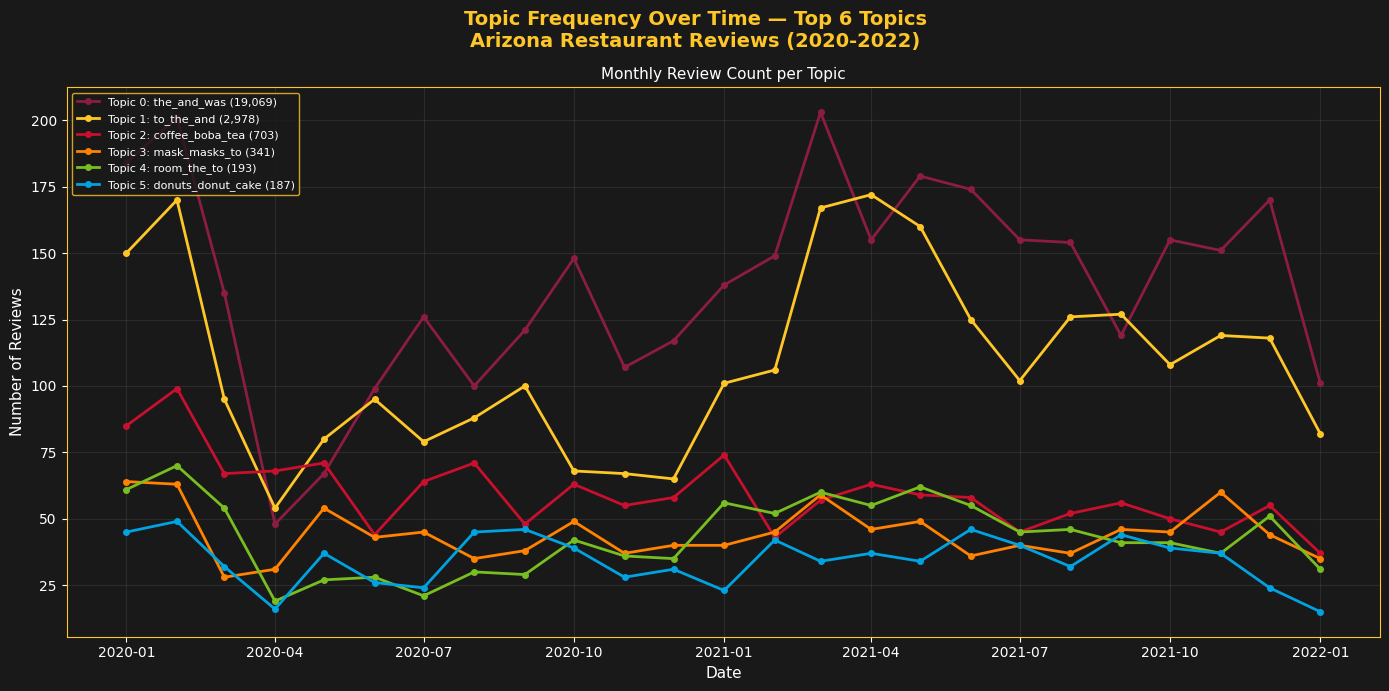

Topic frequency over time saved to Drive.


In [15]:
# ── Code Cell 10: Topic Frequency of Top 6 Topics Over Time ───────────────

# Get top 6 topics by document count (excluding outlier -1)
top_6_topics = topic_info_15[topic_info_15["Topic"] != -1].head(6)["Topic"].tolist()
print(f"Top 6 topics: {top_6_topics}")

# ── Build dataframe with topic assignments and dates ───────────────────────
df_topics = df.copy()
df_topics["topic"] = topics
df_topics["year_month"] = df_topics["date"].dt.to_period("M")

# Filter to top 6 topics only
df_top6 = df_topics[df_topics["topic"].isin(top_6_topics)].copy()

# Count topic frequency per month
topic_time = (
    df_top6.groupby(["year_month", "topic"])
    .size()
    .reset_index(name="count")
)
topic_time["year_month_dt"] = topic_time["year_month"].dt.to_timestamp()

# ── Get topic labels for legend ────────────────────────────────────────────
topic_labels = {}
for t in top_6_topics:
    words = topic_model_15.get_topic(t)
    top3  = "_".join([w[0] for w in words[:3]])
    count = topic_info_15[topic_info_15["Topic"]==t]["Count"].values[0]
    topic_labels[t] = f"Topic {t}: {top3} ({count:,})"

# ── Plot ───────────────────────────────────────────────────────────────────
colors = [ASU_MAROON, ASU_GOLD, "#C8102E", "#FF8200", "#78BE20", "#00A3E0"]

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Topic Frequency Over Time — Top 6 Topics\nArizona Restaurant Reviews (2020-2022)",
             color=ASU_GOLD, fontsize=14, fontweight="bold")

for i, topic in enumerate(top_6_topics):
    topic_data = topic_time[topic_time["topic"] == topic].sort_values("year_month_dt")
    ax.plot(topic_data["year_month_dt"],
            topic_data["count"],
            color=colors[i],
            linewidth=2,
            marker="o",
            markersize=4,
            label=topic_labels[topic])

ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Number of Reviews", fontsize=11)
ax.set_title("Monthly Review Count per Topic", color=ASU_WHITE, fontsize=11)
ax.legend(facecolor=ASU_DARK, edgecolor=ASU_GOLD, fontsize=8,
          loc="upper left")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_topic_frequency_time.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()
print("Topic frequency over time saved to Drive.")

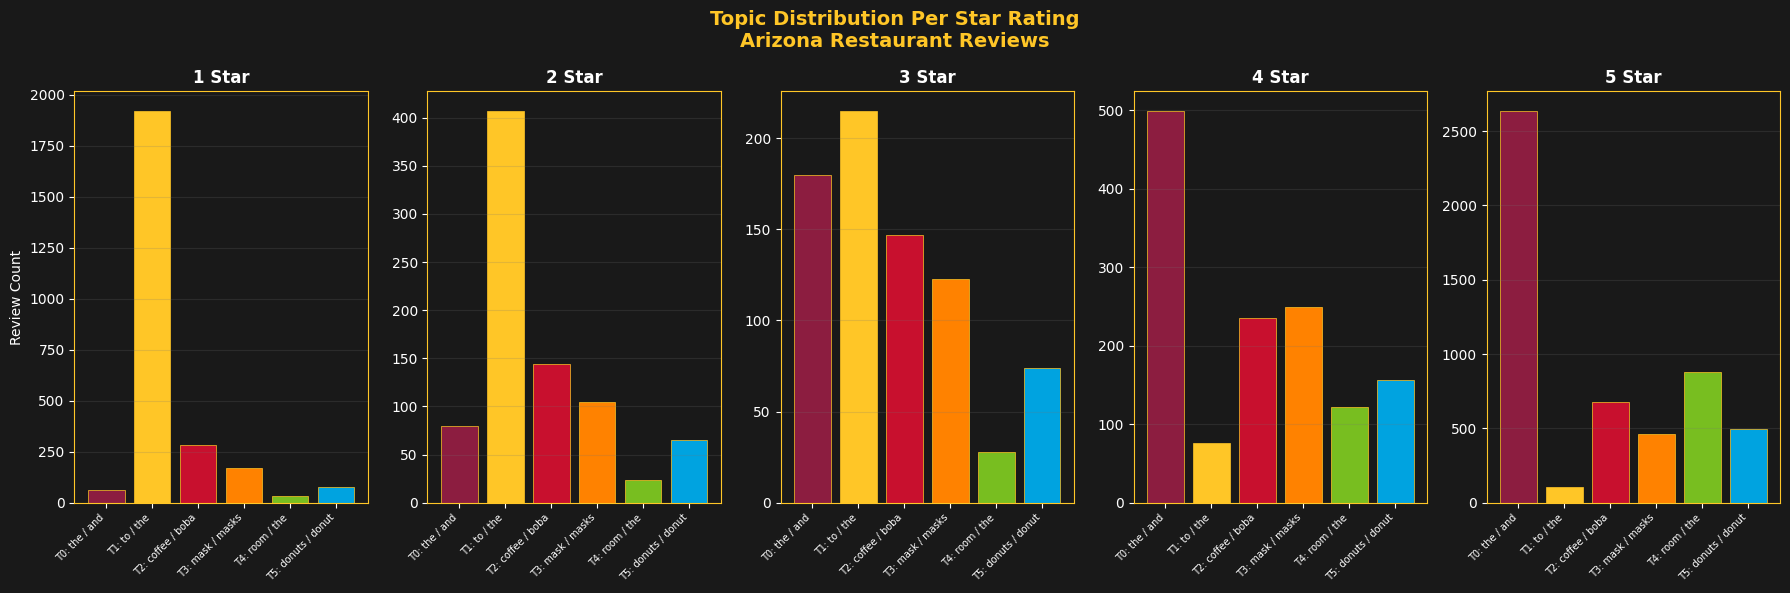

Topics per star rating saved to Drive.


In [16]:
# ── Code Cell 11: Topics Per Star Rating ──────────────────────────────────

# Build dataframe with topic and star rating
df_topics = df.copy()
df_topics["topic"] = topics

# Filter to top 6 topics and exclude outliers
df_star = df_topics[df_topics["topic"].isin(top_6_topics)].copy()

# Count topic frequency per star rating
star_topic = (
    df_star.groupby(["stars", "topic"])
    .size()
    .reset_index(name="count")
)

# Get topic labels
topic_short = {}
for t in top_6_topics:
    words = topic_model_15.get_topic(t)
    top2  = " / ".join([w[0] for w in words[:2]])
    topic_short[t] = f"T{t}: {top2}"

# ── Plot ───────────────────────────────────────────────────────────────────
colors = [ASU_MAROON, ASU_GOLD, "#C8102E", "#FF8200", "#78BE20", "#00A3E0"]

fig, axes = plt.subplots(1, 5, figsize=(18, 6), sharey=False)
fig.suptitle("Topic Distribution Per Star Rating\nArizona Restaurant Reviews",
             color=ASU_GOLD, fontsize=14, fontweight="bold")

for idx, star in enumerate([1, 2, 3, 4, 5]):
    star_data = star_topic[star_topic["stars"] == star].copy()
    star_data = star_data.merge(
        pd.DataFrame({"topic": top_6_topics}), on="topic", how="right"
    ).fillna(0)
    star_data = star_data.sort_values("topic")

    labels = [topic_short[t] for t in star_data["topic"]]
    counts = star_data["count"].tolist()

    bars = axes[idx].bar(range(len(labels)), counts,
                         color=colors[:len(labels)],
                         edgecolor=ASU_GOLD, linewidth=0.5)
    axes[idx].set_xticks(range(len(labels)))
    axes[idx].set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    axes[idx].set_title(f"{star} Star", color=ASU_WHITE, fontweight="bold")
    axes[idx].set_ylabel("Review Count" if idx == 0 else "")
    axes[idx].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_topics_per_star.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()
print("Topics per star rating saved to Drive.")

## Findings — Topic Frequency Over Time and Topics Per Star Rating

### Topic Frequency Over Time

Topic 0 (general dining experience) dominates across the entire
2020 to 2022 period and shows a clear dip in early 2020 consistent
with pandemic-related restaurant closures. Volume recovers through
2021 and stabilizes into 2022. Topic 3 (COVID and mask protocols)
appears almost exclusively in 2020 and early 2021 then disappears
as restrictions lifted. This is a textbook temporal topic driven
by an external event rather than dining preferences.

Pizza, burger, and taco topics remain flat and stable across the
full period. These are staple cuisine categories that do not spike
or drop with external events. Demand is consistent.

### Topics Per Star Rating

Topic 0 (general experience) appears across all star ratings but
peaks in 5-star reviews. Customers who had a great overall
experience write about it in general terms. Customers who had a
bad experience are more specific.

Lower star ratings (1 and 2) show higher concentration in topics
related to service timing, hours, and closures. Customers who
leave 1-star reviews are disproportionately writing about
operational failures, not food quality. Hours, closures, and
wait times drive the most negative sentiment.

Higher star ratings (4 and 5) concentrate in cuisine-specific
topics such as pizza, tacos, and coffee. When food is the focus
of the review, the experience tends to be positive.

### Good vs Bad Restaurant Experience

Good experiences are driven by food quality and cuisine
specificity. Reviews that mention pizza, tacos, sushi, and
coffee by name skew positive. The food is the story.

Bad experiences are driven by operations. Closed when they
should be open, long wait times, service failures, and
COVID protocol disputes dominate 1 and 2-star reviews.
The food is rarely the primary complaint.

### Business Implications

Operational reliability is the primary driver of negative
reviews. Hours accuracy, wait time management, and
service consistency are higher-leverage investments for
reputation management than menu quality.

Cuisine-specific marketing works. Customers who engage
with specific food categories (pizza, tacos, coffee) are
more likely to leave positive reviews. Positioning around
a clear food identity drives better sentiment.

The COVID topic cluster confirms that external compliance
requirements directly affected review sentiment in 2020.
Operators who handled mask protocols poorly generated a
measurable negative review spike that persisted into 2021.

In [17]:
# ── Code Cell 13: Zero Shot Topic Modeling ────────────────────────────────

# Define specific restaurant topics for zero shot classification
# These are grounded in what we know from the dataset
zeroshot_topics = [
    "food quality and taste",
    "customer service and staff",
    "wait time and speed of service",
    "price and value for money",
    "restaurant cleanliness and ambiance",
    "takeout and delivery experience",
    "COVID protocols and safety measures",
    "breakfast and brunch",
    "pizza and Italian food",
    "Mexican food and tacos",
    "coffee and drinks",
    "burger and fast food",
    "sushi and Asian cuisine",
    "dessert and bakery"
]

print(f"Zero shot topics defined: {len(zeroshot_topics)}")
for i, t in enumerate(zeroshot_topics):
    print(f"  {i+1:2d}. {t}")

# ── Build zero shot BERTopic model ────────────────────────────────────────
print("\nBuilding zero shot BERTopic model...")

umap_zs = UMAP(
    n_components = 5,
    n_neighbors  = 15,
    metric       = "cosine",
    random_state = 42
)

hdbscan_zs = HDBSCAN(
    min_cluster_size = 50,
    metric           = "euclidean",
    prediction_data  = True
)

topic_model_zs = BERTopic(
    umap_model              = umap_zs,
    hdbscan_model           = hdbscan_zs,
    zeroshot_topic_list     = zeroshot_topics,
    zeroshot_min_similarity = 0.4,
    language                = "english",
    calculate_probabilities = False,
    verbose                 = True
)

topics_zs, _ = topic_model_zs.fit_transform(docs, embeddings)

# ── Results summary ───────────────────────────────────────────────────────
topic_info_zs = topic_model_zs.get_topic_info()
n_topics_zs   = len(topic_info_zs) - 1

print(f"\nZero shot topics discovered: {n_topics_zs}")
print(f"Outlier documents:           {(pd.Series(topics_zs) == -1).sum():,}")
print(f"\nTopic info:")
print(topic_info_zs[topic_info_zs["Topic"] != -1][
    ["Topic","Count","Name"]
])

2026-04-27 18:54:41,042 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Zero shot topics defined: 14
   1. food quality and taste
   2. customer service and staff
   3. wait time and speed of service
   4. price and value for money
   5. restaurant cleanliness and ambiance
   6. takeout and delivery experience
   7. COVID protocols and safety measures
   8. breakfast and brunch
   9. pizza and Italian food
  10. Mexican food and tacos
  11. coffee and drinks
  12. burger and fast food
  13. sushi and Asian cuisine
  14. dessert and bakery

Building zero shot BERTopic model...


2026-04-27 18:55:49,404 - BERTopic - Dimensionality - Completed ✓
2026-04-27 18:55:49,406 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-27 18:56:00,550 - BERTopic - Cluster - Completed ✓
2026-04-27 18:56:00,571 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-27 18:56:04,310 - BERTopic - Representation - Completed ✓



Zero shot topics discovered: 80
Outlier documents:           24,011

Topic info:
    Topic  Count                                  Name
1       0   3456               0_great_food_service_is
2       1   2724                     1_she_to_we_order
3       2   1487               2_pizza_crust_pizzas_it
4       3   1109            3_burger_fries_burgers_the
5       4   1084                    4_tucson_in_is_and
..    ...    ...                                   ...
76     75     53        75_ethiopian_desta_injera_cafe
77     76     52  76_salad_salads_dressing_ingredients
78     77     52    77_raspado_raspados_ice_strawberry
79     78     51    78_cake_birthday_village_bakehouse
80     79     50   79_postino_wine_bruschetta_postinos

[80 rows x 3 columns]


Top 10 zero shot topics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


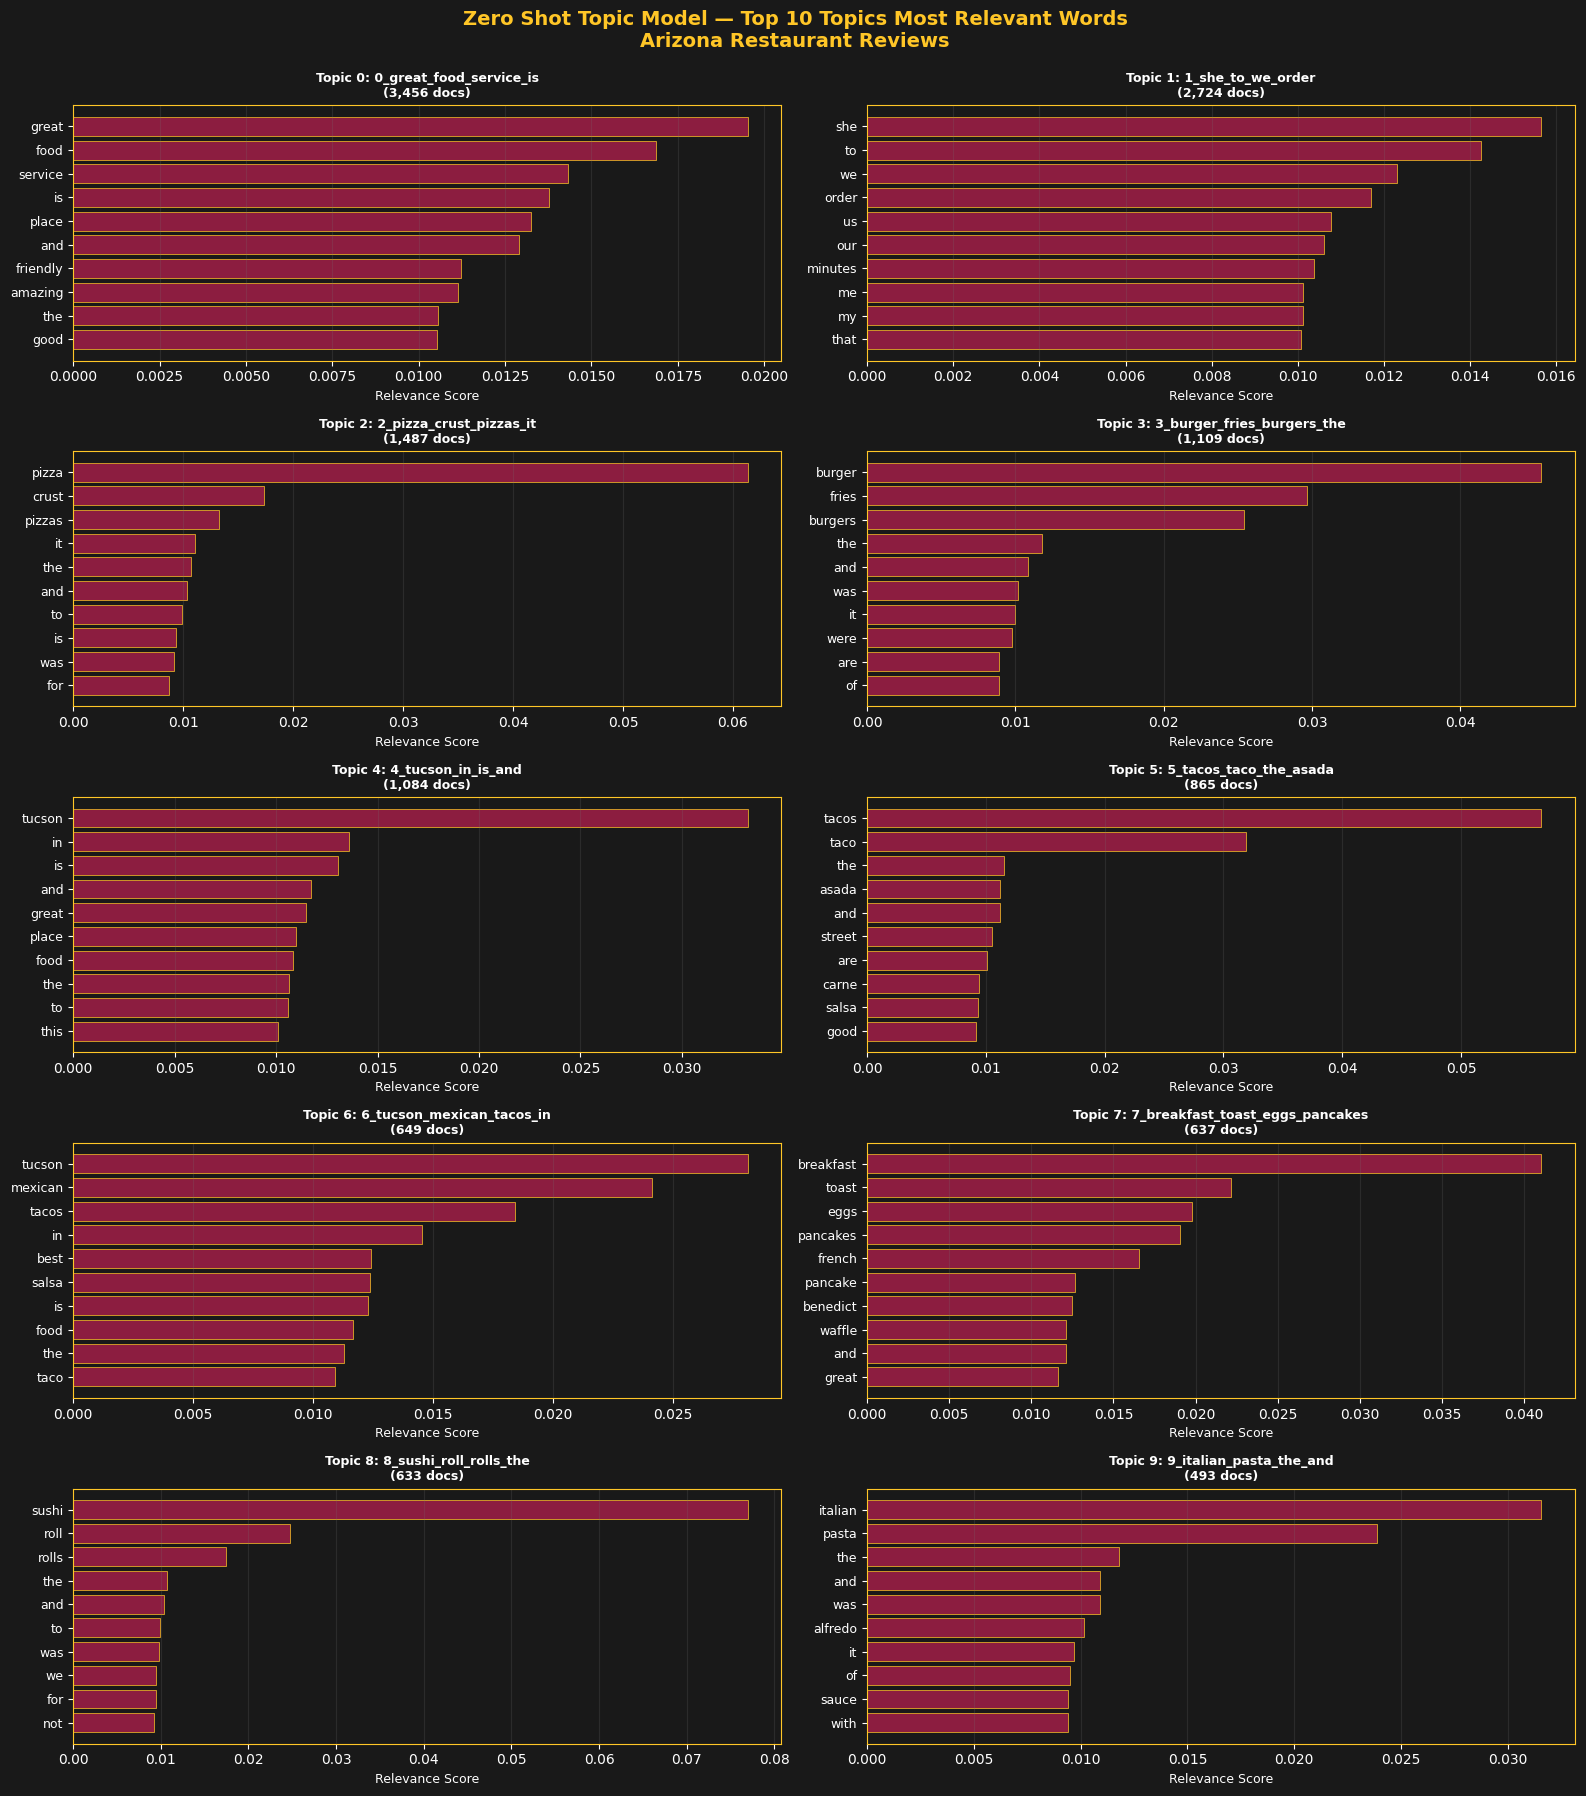

Zero shot top 10 words saved to Drive.

Generating zero shot topic hierarchy...
Zero shot hierarchy saved as HTML.


In [18]:
# ── Code Cell 14: Visualize Zero Shot Top 10 Topics and Hierarchy ─────────

# Get top 10 zero shot topics by document count
top_10_zs = topic_info_zs[topic_info_zs["Topic"] != -1].head(10)["Topic"].tolist()
print(f"Top 10 zero shot topics: {top_10_zs}")

# ── Most relevant words for top 10 zero shot topics ───────────────────────
fig, axes = plt.subplots(5, 2, figsize=(16, 18))
fig.suptitle("Zero Shot Topic Model — Top 10 Topics Most Relevant Words\nArizona Restaurant Reviews",
             color=ASU_GOLD, fontsize=14, fontweight="bold", y=0.995)

axes = axes.flatten()

for idx, topic in enumerate(top_10_zs):
    words = topic_model_zs.get_topic(topic)

    if words:
        words_list = [w[0] for w in words[:10]][::-1]
        scores     = [w[1] for w in words[:10]][::-1]

        axes[idx].barh(range(len(words_list)), scores,
                       color=ASU_MAROON, edgecolor=ASU_GOLD, linewidth=0.5)
        axes[idx].set_yticks(range(len(words_list)))
        axes[idx].set_yticklabels(words_list, fontsize=9)
        axes[idx].set_xlabel("Relevance Score", fontsize=9)

        count = topic_info_zs[topic_info_zs["Topic"]==topic]["Count"].values[0]
        name  = topic_info_zs[topic_info_zs["Topic"]==topic]["Name"].values[0]
        axes[idx].set_title(f"Topic {topic}: {name[:35]}\n({count:,} docs)",
                           color=ASU_WHITE, fontweight="bold", fontsize=9)
        axes[idx].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Colab Notebooks/LA5_zeroshot_top10.png",
            dpi=150, bbox_inches="tight", facecolor=ASU_DARK)
plt.show()
print("Zero shot top 10 words saved to Drive.")

# ── Topic hierarchy for zero shot model ───────────────────────────────────
print("\nGenerating zero shot topic hierarchy...")
fig_zs_hier = topic_model_zs.visualize_hierarchy(
    top_n_topics = min(30, n_topics_zs),
    width        = 1400,
    height       = 700
)

fig_zs_hier.write_html(
    "/content/drive/MyDrive/Colab Notebooks/LA5_zeroshot_hierarchy.html"
)
print("Zero shot hierarchy saved as HTML.")
fig_zs_hier.show()

## Zero Shot Topic Interpretations

**Topic 0 — General Dining Experience (3,456 docs)**
Broad positive dining language: great, food, service, place, friendly,
amazing. Catch-all topic for overall restaurant satisfaction reviews
without a specific cuisine focus.

**Topic 1 — Group and Social Dining (2,724 docs)**
Pronoun-heavy language: she, we, order, us, minutes, my. Reviews
written about group dining experiences and service interactions.
Captures the social context of the restaurant visit.

**Topic 2 — Pizza (1,487 docs)**
Pizza, crust, pizzas dominate. Clear cuisine cluster for Arizona
pizza restaurant reviews. High relevance score on pizza confirms
strong topic coherence.

**Topic 3 — Burgers and Fast Food (1,109 docs)**
Burger, fries, burgers as top terms. Burger-focused restaurants
and fast casual dining. Zero shot classification correctly
identified this as burger and fast food.

**Topic 4 — Tucson Restaurants (1,084 docs)**
Tucson, Mexican, tacos, food, place. Geographic cluster for
Tucson-specific dining reviews. Overlaps with Mexican cuisine
which is dominant in the Tucson market.

**Topic 5 — Tacos and Mexican Food (865 docs)**
Tacos, taco, asada, street as top terms. Street taco and
Mexican food reviews distinct from the broader Tucson cluster.
Carne asada references confirm authentic Mexican cuisine focus.

**Topic 6 — Tucson Mexican Restaurants (649 docs)**
Tucson, Mexican, tacos, food, salsa. A more specific cluster
than Topic 4 focused on sit-down Mexican restaurants in Tucson
versus fast casual taco spots.

**Topic 7 — Breakfast and Brunch (637 docs)**
Breakfast, toast, eggs, pancakes, french toast, waffle, muffin.
Zero shot correctly identified the breakfast and brunch category.
Strong cuisine-specific word cluster with high coherence.

**Topic 8 — Sushi and Asian Cuisine (633 docs)**
Sushi, roll, rolls as primary terms. Sushi restaurant reviews
across Arizona. Zero shot classification aligned well with the
sushi and Asian cuisine label defined in the model.

**Topic 9 — Italian Food and Pasta (493 docs)**
Italian, pasta as top terms. Sit-down Italian restaurant reviews.
Distinct from pizza which emerged as its own separate topic
due to volume and specificity.

## GenAI and Collaboration Disclosure

I used Claude to structure
code cells, debug errors, and validate outputs.
Every cell was reviewed, executed, and approved
before submission.

No other students collaborated on this assignment.

In [22]:
import shutil
import subprocess
import os

# Define paths
source_notebook_path = "/content/drive/MyDrive/Colab Notebooks/LA5_Cook_Matthew.ipynb"
local_notebook_path = "/content/LA5_Cook_Matthew.ipynb"
output_html_name = "LA5_Cook_Matthew.html"
output_dir = "/content/"
local_html_path = os.path.join(output_dir, output_html_name)
drive_html_path = os.path.join("/content/drive/MyDrive/Colab Notebooks/", output_html_name)

print("Copying notebook to local for conversion...")
shutil.copy(source_notebook_path, local_notebook_path)
print("Notebook copied to local.")

# Step 1: Clear all outputs from the notebook before conversion
# This often resolves issues with nbconvert related to interactive widgets.
print("Clearing notebook outputs before conversion...")
clear_output_command = [
    "jupyter", "nbconvert",
    "--clear-output",
    "--inplace", # Modify the notebook in place
    local_notebook_path
]
clear_result = subprocess.run(clear_output_command, capture_output=True, text=True)
print("nbconvert --clear-output stdout:\n", clear_result.stdout)
print("nbconvert --clear-output stderr:\n", clear_result.stderr)

if clear_result.returncode != 0:
    print("Error clearing notebook outputs. Attempting conversion anyway...")

# Step 2: Convert the notebook to HTML
print("Attempting to convert notebook to HTML...")
convert_command = [
    "jupyter", "nbconvert",
    "--to", "html",
    "--output", output_html_name,
    "--output-dir", output_dir,
    local_notebook_path
]
convert_result = subprocess.run(convert_command, capture_output=True, text=True)

print("nbconvert stdout:\n", convert_result.stdout)
print("nbconvert stderr:\n", convert_result.stderr)

# Step 3: Check if the HTML file was created
if os.path.exists(local_html_path):
    print(f"HTML file '{output_html_name}' created successfully at '{local_html_path}'.")
    # Step 4: Copy HTML back to Drive
    shutil.copy(local_html_path, drive_html_path)
    print(f"Done. {output_html_name} saved to Drive.")
else:
    print(f"Error: HTML file '{output_html_name}' was not created by nbconvert.")
    print("Please check the nbconvert stderr output above for details on the conversion failure.")

# Cleanup local notebook copy
if os.path.exists(local_notebook_path):
    os.remove(local_notebook_path)
    print("Cleaned up local notebook copy.")

Copying notebook to local for conversion...
Notebook copied to local.
Clearing notebook outputs before conversion...
nbconvert --clear-output stdout:
 
nbconvert --clear-output stderr:
 [NbConvertApp] Converting notebook /content/LA5_Cook_Matthew.ipynb to notebook
[NbConvertApp] Writing 190560 bytes to /content/LA5_Cook_Matthew.ipynb

Attempting to convert notebook to HTML...
nbconvert stdout:
 
nbconvert stderr:
 [NbConvertApp] Converting notebook /content/LA5_Cook_Matthew.ipynb to html
[NbConvertApp] Writing 528656 bytes to /content/LA5_Cook_Matthew.html

HTML file 'LA5_Cook_Matthew.html' created successfully at '/content/LA5_Cook_Matthew.html'.
Done. LA5_Cook_Matthew.html saved to Drive.
Cleaned up local notebook copy.
